<a href="https://colab.research.google.com/github/ChrisJavier/UIDE_3-WorkGroupProyects/blob/main/week_3/src/AMGD_CP_W3_E3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 🧠 Trabajo 3: Ejercicio de Aplicacion Autónoma

## 📋 Información del Proyecto
- Autores:
  - CARRERA DIAZ CHRISTIAN JAVIER
  - CERNA PACHECO ROMEL MICHAEL
  - LUNA ARTEAGA ALEXANDER PAUL
- Versión: 1.0.0
- Licencia: MIT


🎯 Introducción:

Consolidar los conceptos de limpieza y transformación de datos, prevención de data
leakage y diseño de pipelines reproducibles, integrando herramientas programáticas
como Python y entornos visuales como Orange Data Mining. Para el desarrollo del
trabajo, se recomienda utilizar Google Colab, que permite escribir y ejecutar código
Python en la nube desde el navegador web, así como integrar bloques de texto en
formato Markdown para la documentación técnica y metodológica.
La entrega debe incluir un único documento tipo notebook en formato .ipynb, junto con
los archivos adicionales solicitados en la actividad. El nombre del archivo debe seguir
estrictamente el formato: “AMGD_CP_W3_E#”, donde “#” corresponde al número de
equipo. Adicionalmente, se deberá adjuntar un documento en Word que contenga las
capturas del modelo desarrollado en Orange y una síntesis de las principales
discusiones, decisiones metodológicas y resultados obtenidos.

**🌍 Contexto del trabajo**

Los estudiantes deberán seleccionar un dataset público o una API de su interés
(preferiblemente relacionada con su área de estudio o trabajo). El objetivo es obtener datos
de esta fuente, realizar un proceso de limpieza y exploración inicial, y luego aplicar
transformaciones para realizar las validaciones realizadas en la arquitectura de orange.

# 1️⃣ Fase 1: Análisis en Python (Pipeline Profesional):

*******************************************************************************

## 🎯 **1.1. Objetivo general del proyecto**

Evaluar el impacto metodológico del uso correcto e incorrecto del preprocesamiento de datos en un problema de clasificación aplicado al dataset de vehículos nuevos registrados en el Servicio de Rentas Internas, mediante validación cruzada y comparación de métricas de desempeño.

##📌 **1.2. Justificación del proyecto**

Para este proyecto decidimos evidenciar cómo el diseño correcto del preprocesamiento impacta la validez y confiabilidad de los modelos de clasificación. Al comparar un enfoque con posible data leakage frente a uno basado en Pipeline y validación cruzada, se busca demostrar diferencias reales en desempeño y generalización. El análisis aplicado al dataset de vehículos del SRI permite integrar fundamentos metodológicos con un caso práctico. Así, se refuerzan buenas prácticas en arquitectura y reproducibilidad en Ciencia de Datos.

## ✅ **1.3. Objetivos específicos**

1️⃣ Seleccionar un dataset estructurado de clasificación
- Utilizar el dataset de vehículos nuevos registrados en el SRI.
- Garantizar un mínimo de 10 variables predictoras.
- Definir claramente la variable objetivo (por ejemplo: tipo de vehículo, segmento, categoría de precio, tipo de combustible, etc.).

2️⃣ Realizar análisis exploratorio de datos (EDA)
- Analizar la distribución de variables numéricas y categóricas.
- Identificar valores faltantes y evaluar su tratamiento.
- Detectar posibles outliers y su impacto en el modelado.
- Examinar correlaciones preliminares entre variables.

3️⃣ Implementar dos enfoques de modelado

- Enfoque metodológicamente incorrecto

  - Aplicar transformaciones (normalización, imputación, selección de variables) antes de la validación cruzada.
  - Evidenciar posible data leakage.

- Enfoque metodológicamente correcto

  - Construir un Pipeline de sklearn que incluya:
  - Preprocesamiento (imputación, escalado, codificación).
  - Modelo de clasificación.
  - Integrar todo el flujo dentro de la validación cruzada.  

4️⃣ Comparar métricas de desempeño

- Utilizar validación cruzada (k-fold).
- Comparar métricas como:
  - Accuracy
  - Precision
  - Recall
  - F1-score
- Analizar estabilidad de resultados (media y desviación estándar).

5️⃣ Analizar resultados y explicar el impacto arquitectónico

- Evaluar diferencias en desempeño entre ambos enfoques.
- Identificar evidencia de data leakage.
- Explicar la importancia del diseño arquitectónico del pipeline en términos de:
  - Reproducibilidad.
  - Generalización.
  - Integridad experimental.
  - Buenas prácticas en MLOps.

## 🔗 1.4. Enlaces del Dataset que se usaran

La información usada esta en la pagina oficial del INEC https://www.censoecuador.gob.ec/data-censo-ecuador/ que nos ofrece el dataset con todos sus complementos como la encuenta realizada, el diccionario de datos, etc.

- Dataset del registro de vehiculos nuevos registrados por el SRI 2025: https://www.sri.gob.ec/datasets#Ventas%20-%20Compras


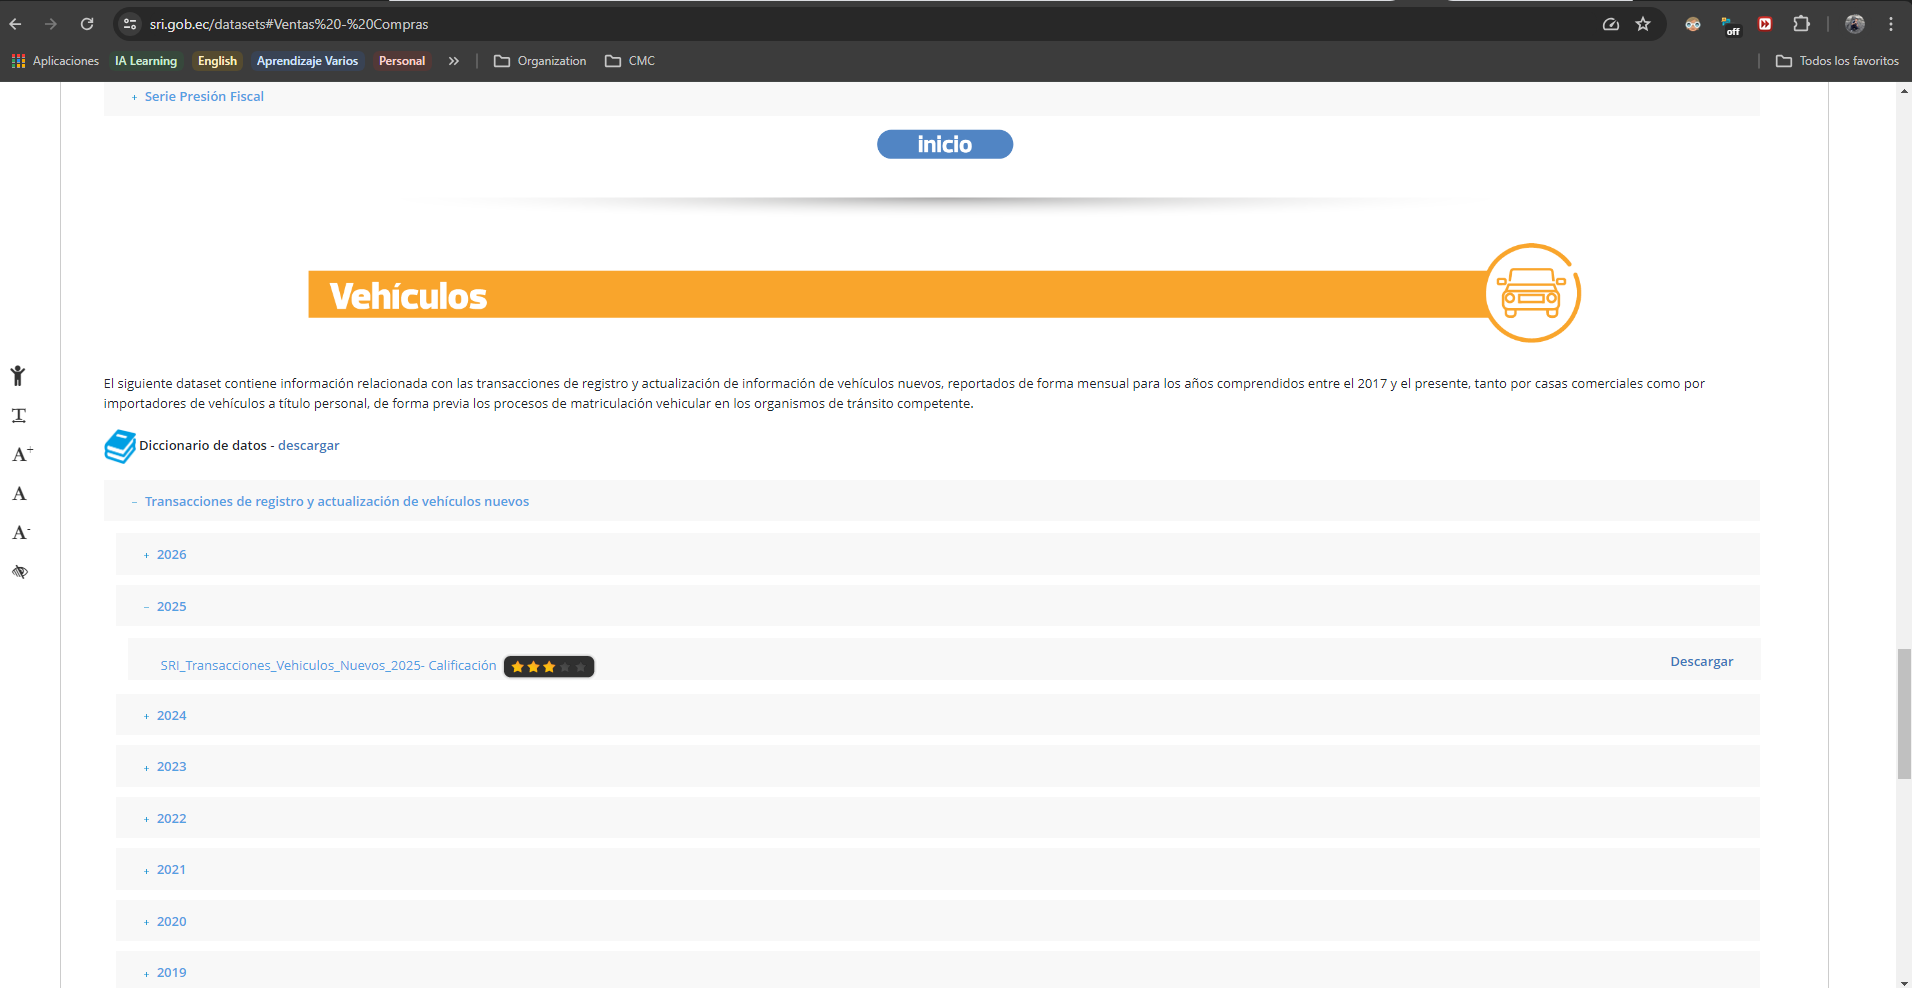




## 🚀 1.5. Descarga del dataset

El dataset contiene información relacionada con las transacciones de registro y actualización de información de vehículos nuevos, reportados de forma mensual para los años comprendidos entre el 2017 y el presente, tanto por casas comerciales como por importadores de vehículos a título personal, de forma previa los procesos de matriculación vehicular en los organismos de tránsito competente.

📥 Este código descarga un archivo csv y seleccionamos el dataset de vehiculos nuevos registrados por el SRI.

In [2]:
 # importacion de la libreria os que permite interactuar con el sistema operativo (archivos y rutas)

import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Define el nombre del archivo comprimido que se descargará
bought_sold_cars = 'Bought_Sold_Cars2025.csv'

# Descarga el archivo csv del sitio oficial del SRI
# El archivo se guarda en el entorno de trabajo actual y valido que si existe no lo descargue de nuevo

if not os.path.exists(bought_sold_cars) and not os.path.exists(bought_sold_cars):
  !wget --timeout=15 --tries=2 'https://descargas.sri.gob.ec/download/datosAbiertos/SRI_Vehiculos_Nuevos_2025.csv' -O '{bought_sold_cars}'
  # Validamos si se descargo el archivo sino vamos por otra alternativa
while True:
  try:
      # Leer el archivo
      df = pd.read_csv(bought_sold_cars, sep=';',encoding='latin-1')
      # Verificar si el DataFrame está vacío
      if df.empty:
          !wget 'https://github.com/ChrisJavier/UIDE_3-WorkGroupProyects/raw/refs/heads/main/week_3/src/Bought_Sold_Cars2025.csv' -O '{bought_sold_cars}'
      else:
          print("CSV válido")
          break
  except Exception as e:
      !wget 'https://github.com/ChrisJavier/UIDE_3-WorkGroupProyects/raw/refs/heads/main/week_3/src/Bought_Sold_Cars2025.csv' -O '{bought_sold_cars}'
      print(f"Error al leer el archivo CSV, {e}")



--2026-02-25 00:19:11--  https://descargas.sri.gob.ec/download/datosAbiertos/SRI_Vehiculos_Nuevos_2025.csv
Resolving descargas.sri.gob.ec (descargas.sri.gob.ec)... 181.188.238.11
Connecting to descargas.sri.gob.ec (descargas.sri.gob.ec)|181.188.238.11|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 78667373 (75M) [text/csv]
Saving to: ‘Bought_Sold_Cars2025.csv’

Bought_Sold_Cars202 100%[===================>]  75.02M  1.37MB/s    in 56s     

2026-02-25 00:20:08 (1.34 MB/s) - ‘Bought_Sold_Cars2025.csv’ saved [78667373/78667373]

CSV válido


## 🚀 1.6. Previsualizacion y validacion

📥 Carga el dataset desde un archivo CSV comprimido, valida que tenga al menos 10.000 registros y muestra un resumen estadístico de sus columnas numéricas.

In [3]:
# Visualizamos un breve informacion del dataset
df.info()

# Valida que el dataset tenga al menos 10.000 registros, como solicita el ejercicio
if df.shape[0] < 10000:
    # Lanza una excepción si no se cumple el mínimo de registros
    raise Exception
else:
  # Muestra un mensaje de confirmación si el dataset es válido
  print(f'Dataset validado, el dataset contiene {df.shape[0]} registros \n')

# Muestra un resumen estadístico de las columnas numéricas del dataset
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 482754 entries, 0 to 482753
Data columns (total 20 columns):
 #   Column                      Non-Null Count   Dtype 
---  ------                      --------------   ----- 
 0   CATEGORÍA                   482754 non-null  int64 
 1   CÓDIGO DE VEHÍCULO          482754 non-null  int64 
 2   TIPO TRANSACCIÓN            482754 non-null  object
 3   MARCA                       482754 non-null  object
 4   MODELO                      482754 non-null  object
 5   PAIS                        482754 non-null  object
 6   AÑO MODELO                  482754 non-null  int64 
 7   CLASE                       482754 non-null  object
 8   SUB CLASE                   482754 non-null  object
 9   TIPO                        482754 non-null  object
 10  AVALUO                      482754 non-null  object
 11  FECHA PROCESO (DD/MM/AAAA)  482754 non-null  object
 12  TIPO SERVICIO               482754 non-null  object
 13  CILINDRAJE                  4

,CATEGORÍA,CÓDIGO DE VEHÍCULO,AÑO MODELO,CILINDRAJE,CANTÓN
count,482754.000000,4.827540e+05,482754.000000,482754.000000,482754.000000
mean,94519.796329,9.964513e+06,2025.404401,869.634953,16414.136349
std,9294.228519,3.384611e+05,0.842111,1420.289536,6177.740167
min,29.000000,1.920717e+06,1979.000000,0.000000,10701.000000
25%,90034.000000,9.822290e+06,2025.000000,149.000000,10927.000000
50%,98577.000000,9.997460e+06,2026.000000,200.000000,11321.000000
75%,99980.000000,1.018095e+07,2026.000000,1494.000000,21701.000000
max,104856.000000,1.049422e+07,2027.000000,18037.000000,42003.000000


## 🚀 1.7. Transformacion de datos

🔍 Cambio de valores de fechas, eliminar los caracteres especiales y eliminar duplicados  de las columnas

In [4]:
# Adecuamos las columnas colocandole nombres en minusculas y sin caracteres especiales
import unicodedata

def quitar_tildes(texto):
    texto_normalizado = unicodedata.normalize('NFD', texto)
    texto_sin_tildes = ''.join(
        c for c in texto_normalizado
        if unicodedata.category(c) != 'Mn'
    )
    return texto_sin_tildes

# Eliminacion de caracteres especial
df.columns = [quitar_tildes(col).lower().rstrip().replace(' ','_').replace('_(dd/mm/aaaa)','').replace('-','') for col in df.columns]

# Convertimos los tipos de datos de las columnas necesarias

df['fecha_compra'] = pd.to_datetime(df['fecha_compra'])
df['fecha_proceso'] = pd.to_datetime(df['fecha_proceso'])
df['avaluo'] = df['avaluo'].str.replace(",", ".", regex=False).astype(float)

# Visualizamos los registros duplicados del dataset
print(f'Registros duplicados: {df.duplicated().sum()}, representa el {(df.duplicated().sum()/df.shape[0])*100} %\n')

# Eliminamos los registros duplicados
df = df.drop_duplicates()
# Visualizacion de los nuevos datos
df.info()


/tmp/ipython-input-68810805.py:17: UserWarning: Parsing dates in %d/%m/%Y format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  df['fecha_compra'] = pd.to_datetime(df['fecha_compra'])
/tmp/ipython-input-68810805.py:18: UserWarning: Parsing dates in %d/%m/%Y format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  df['fecha_proceso'] = pd.to_datetime(df['fecha_proceso'])


Registros duplicados: 46152, representa el 9.560148647137051 %

<class 'pandas.core.frame.DataFrame'>
Index: 436602 entries, 0 to 482753
Data columns (total 20 columns):
 #   Column                     Non-Null Count   Dtype         
---  ------                     --------------   -----         
 0   categoria                  436602 non-null  int64         
 1   codigo_de_vehiculo         436602 non-null  int64         
 2   tipo_transaccion           436602 non-null  object        
 3   marca                      436602 non-null  object        
 4   modelo                     436602 non-null  object        
 5   pais                       436602 non-null  object        
 6   ano_modelo                 436602 non-null  int64         
 7   clase                      436602 non-null  object        
 8   sub_clase                  436602 non-null  object        
 9   tipo                       436602 non-null  object        
 10  avaluo                     436602 non-null  float64      

🔍 Reemplazamos los valores de las columnas de acuerdo al diccionario de datos que nos trae los valores de canton y provincia.

In [5]:
# Creamos los diccionarios de canton y provincia

canton = {20115:"CAMILO PONCE ENRIQUEZ",20111:"CHORDELEG",20101:"CUENCA",20112:"EL PAN",20102:"GIRON",20114:"GUACHAPALA",20103:"GUALACEO",20104:"NABON",20110:"OÑA",20105:"PAUTE",20106:"PUCARA",20107:"SAN FERNANDO",20108:"SANTA ISABEL",20113:"SEVILLA DE ORO",20109:"SIGSIG",20206:"CALUMA",20202:"CHILLANES",20203:"CHIMBO",20204:"ECHEANDIA",20201:"GUARANDA",20207:"LAS NAVES",20205:"SAN MIGUEL",20301:"AZOGUES",20302:"BIBLIAN",20303:"CAÑAR",20306:"DELEG",20305:"EL TAMBO",20304:"LA TRONCAL",20307:"SUSCAL",20402:"BOLIVAR",20403:"ESPEJO",20404:"MIRA",20405:"MONTUFAR",20406:"SAN PEDRO DE HUACA",20401:"TULCAN",20602:"ALAUSI",20604:"CHAMBO",20605:"CHUNCHI",20603:"COLTA",20610:"CUMANDA",20606:"GUAMOTE",20607:"GUANO",20608:"PALLATANGA",20609:"PENIPE",20601:"RIOBAMBA",20502:"LA MANA",20501:"LATACUNGA",20503:"PANGUA",20504:"PUJILI",20505:"SALCEDO",20506:"SAQUISILI",20507:"SIGCHOS",10702:"ARENILLAS",10703:"ATAHUALPA",10704:"BALSAS",10705:"CHILLA",10706:"EL GUABO",10707:"HUAQUILLAS",10714:"LAS LAJAS",10701:"MACHALA",10708:"MARCABELI",10709:"PASAJE",10710:"PIÑAS",10711:"PORTOVELO",10712:"SANTA ROSA",10713:"ZARUMA",10806:"ATACAMES",10802:"ELOY ALFARO",10801:"ESMERALDAS",10808:"LA CONCORDIA",10803:"MUISNE",10804:"QUININDE",10807:"RIO VERDE",10805:"SAN LORENZO",42002:"ISABELA",42001:"SAN CRISTOBAL",42003:"SANTA CRUZ",10902:"ALFREDO BAQUERIZO MORENO (JUJAN)",10903:"BALAO",10904:"BALZAR",10905:"COLIMES",10923:"CORONEL MARCELINO MARIDUEÑA",10906:"DAULE",10907:"DURAN",10908:"EL EMPALME",10909:"EL TRIUNFO",10927:"GENERAL ANTONIO ELIZALDE",10901:"GUAYAQUIL",10928:"ISIDRO AYORA",10924:"LOMAS DE SARGENTILLO",10910:"MILAGRO",10911:"NARANJAL",10912:"NARANJITO",10925:"NOBOL (VICENTE PIEDRAHITA)",10913:"PALESTINA",10914:"PEDRO CARBO",10921:"PLAYAS (GENERAL VILLAMIL)",10919:"SALITRE",10916:"SAMBORONDON",10920:"SAN JACINTO DE YAGUACHI",10918:"SANTA LUCIA",10922:"SIMON BOLIVAR",21002:"ANTONIO ANTE",21003:"COTACACHI",21001:"IBARRA",21004:"OTAVALO",21005:"PIMAMPIRO",21006:"SAN MIGUEL DE URCUQUI",21102:"CALVAS",21103:"CATAMAYO",21104:"CELICA",21105:"CHAHUARPAMBA",21106:"ESPINDOLA",21107:"GONZANAMA",21101:"LOJA",21108:"MACARA",21116:"OLMEDO",21109:"PALTAS",21114:"PINDAL",21110:"PUYANGO",21115:"QUILANGA",21111:"SARAGURO",21112:"SOZORANGA",21113:"ZAPOTILLO",11202:"BABA",11201:"BABAHOYO",11210:"BUENA FE",11212:"MOCACHE",11203:"MONTALVO",11209:"PALENQUE",11204:"PUEBLO VIEJO",11205:"QUEVEDO",11213:"QUINSALOMA",11206:"URDANETA",11211:"VALENCIA",11207:"VENTANAS",11208:"VINCES",11316:"24 DE MAYO",11302:"BOLIVAR",11303:"CHONE",11304:"EL CARMEN",11305:"FLAVIO ALFARO",11320:"JAMA",11321:"JARAMIJO",11306:"JIPIJAPA",11307:"JUNIN",11308:"MANTA",11309:"MONTECRISTI",11318:"OLMEDO",11310:"PAJAN",11317:"PEDERNALES",11311:"PICHINCHA",11301:"PORTOVIEJO",11319:"PUERTO LOPEZ",11312:"ROCAFUERTE",11322:"SAN VICENTE",11313:"SANTA ANA",11314:"SUCRE",11315:"TOSAGUA",31402:"GUALAQUIZA",31407:"HUAMBOYA",31403:"LIMON - INDANZA",31410:"LOGROÑO",31401:"MORONA",31411:"PABLO SEXTO",31404:"PALORA",31408:"SAN JUAN BOSCO",31405:"SANTIAGO",31406:"SUCUA",31409:"TAISHA",31412:"TIWINTZA",31503:"ARCHIDONA",31509:"CARLOS JULIO AROSEMENA TOLA",31504:"EL CHACO",31507:"QUIJOS",31501:"TENA",32202:"AGUARICO",32201:"FRANCISCO DE ORELLANA",32203:"LA JOYA DE LOS SACHAS",32204:"LORETO",31604:"ARAJUNO",31602:"MERA",31601:"PASTAZA",31603:"SANTA CLARA",21702:"CAYAMBE",21703:"MEJIA",21704:"PEDRO MONCAYO",21708:"PEDRO VICENTE MALDONADO",21709:"PUERTO QUITO",21701:"QUITO",21705:"RUMIÑAHUI",21707:"SAN MIGUEL DE LOS BANCOS",12402:"LA LIBERTAD",12403:"SALINAS",12401:"SANTA ELENA",22301:"SANTO DOMINGO",32106:"CASCALES",32107:"CUYABENO",32102:"GONZALO PIZARRO",32101:"LAGO AGRIO",32103:"PUTUMAYO",32104:"SHUSHUFINDI",32105:"SUCUMBIOS",21801:"AMBATO",21802:"BAÑOS DE AGUA SANTA",21803:"CEVALLOS",21804:"MOCHA",21805:"PATATE",21806:"QUERO",21807:"SAN PEDRO DE PELILEO",21808:"SANTIAGO DE PILLARO",21809:"TISALEO",31907:"CENTINELA DEL CONDOR",31902:"CHINCHIPE",31906:"EL PANGUI",31903:"NANGARITZA",31908:"PALANDA",31909:"PAQUISHA",31904:"YACUAMBI",31905:"YANTZAZA (YANZATZA)",31901:"ZAMORA"}

provincias = {201:"AZUAY", 202:"BOLIVAR", 203:"CAÑAR", 204:"CARCHI", 206:"CHIMBORAZO", 205:"COTOPAXI", 107:"EL ORO", 108:"ESMERALDAS", 420:"GALAPAGOS", 109:"GUAYAS", 210:"IMBABURA", 211:"LOJA", 112:"LOS RIOS", 113:"MANABI", 314:"MORONA SANTIAGO", 315:"NAPO", 322:"ORELLANA", 316:"PASTAZA", 217:"PICHINCHA", 124:"SANTA ELENA", 223:"SANTO DOMINGO DE LOS TSÁCHILAS", 321:"SUCUMBIOS", 218:"TUNGURAHUA", 319:"ZAMORA CHINCHIPE"}

# Vamos a crear la columna de provincias con los valores que tenemos

df['provincia'] = df['canton'].map(canton)

# Reemplazamos los valores de la columna de canton con el nuevo diccionario

df['canton'] = df['canton'].map(canton)

# Visualizamos el cambio
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 436602 entries, 0 to 482753
Data columns (total 21 columns):
 #   Column                     Non-Null Count   Dtype         
---  ------                     --------------   -----         
 0   categoria                  436602 non-null  int64         
 1   codigo_de_vehiculo         436602 non-null  int64         
 2   tipo_transaccion           436602 non-null  object        
 3   marca                      436602 non-null  object        
 4   modelo                     436602 non-null  object        
 5   pais                       436602 non-null  object        
 6   ano_modelo                 436602 non-null  int64         
 7   clase                      436602 non-null  object        
 8   sub_clase                  436602 non-null  object        
 9   tipo                       436602 non-null  object        
 10  avaluo                     436602 non-null  float64       
 11  fecha_proceso              436602 non-null  datetime64[ns

## 🚀 1.8. Limpieza y Exploración Inicial (Análisis Exploratorio de Datos - EDA):

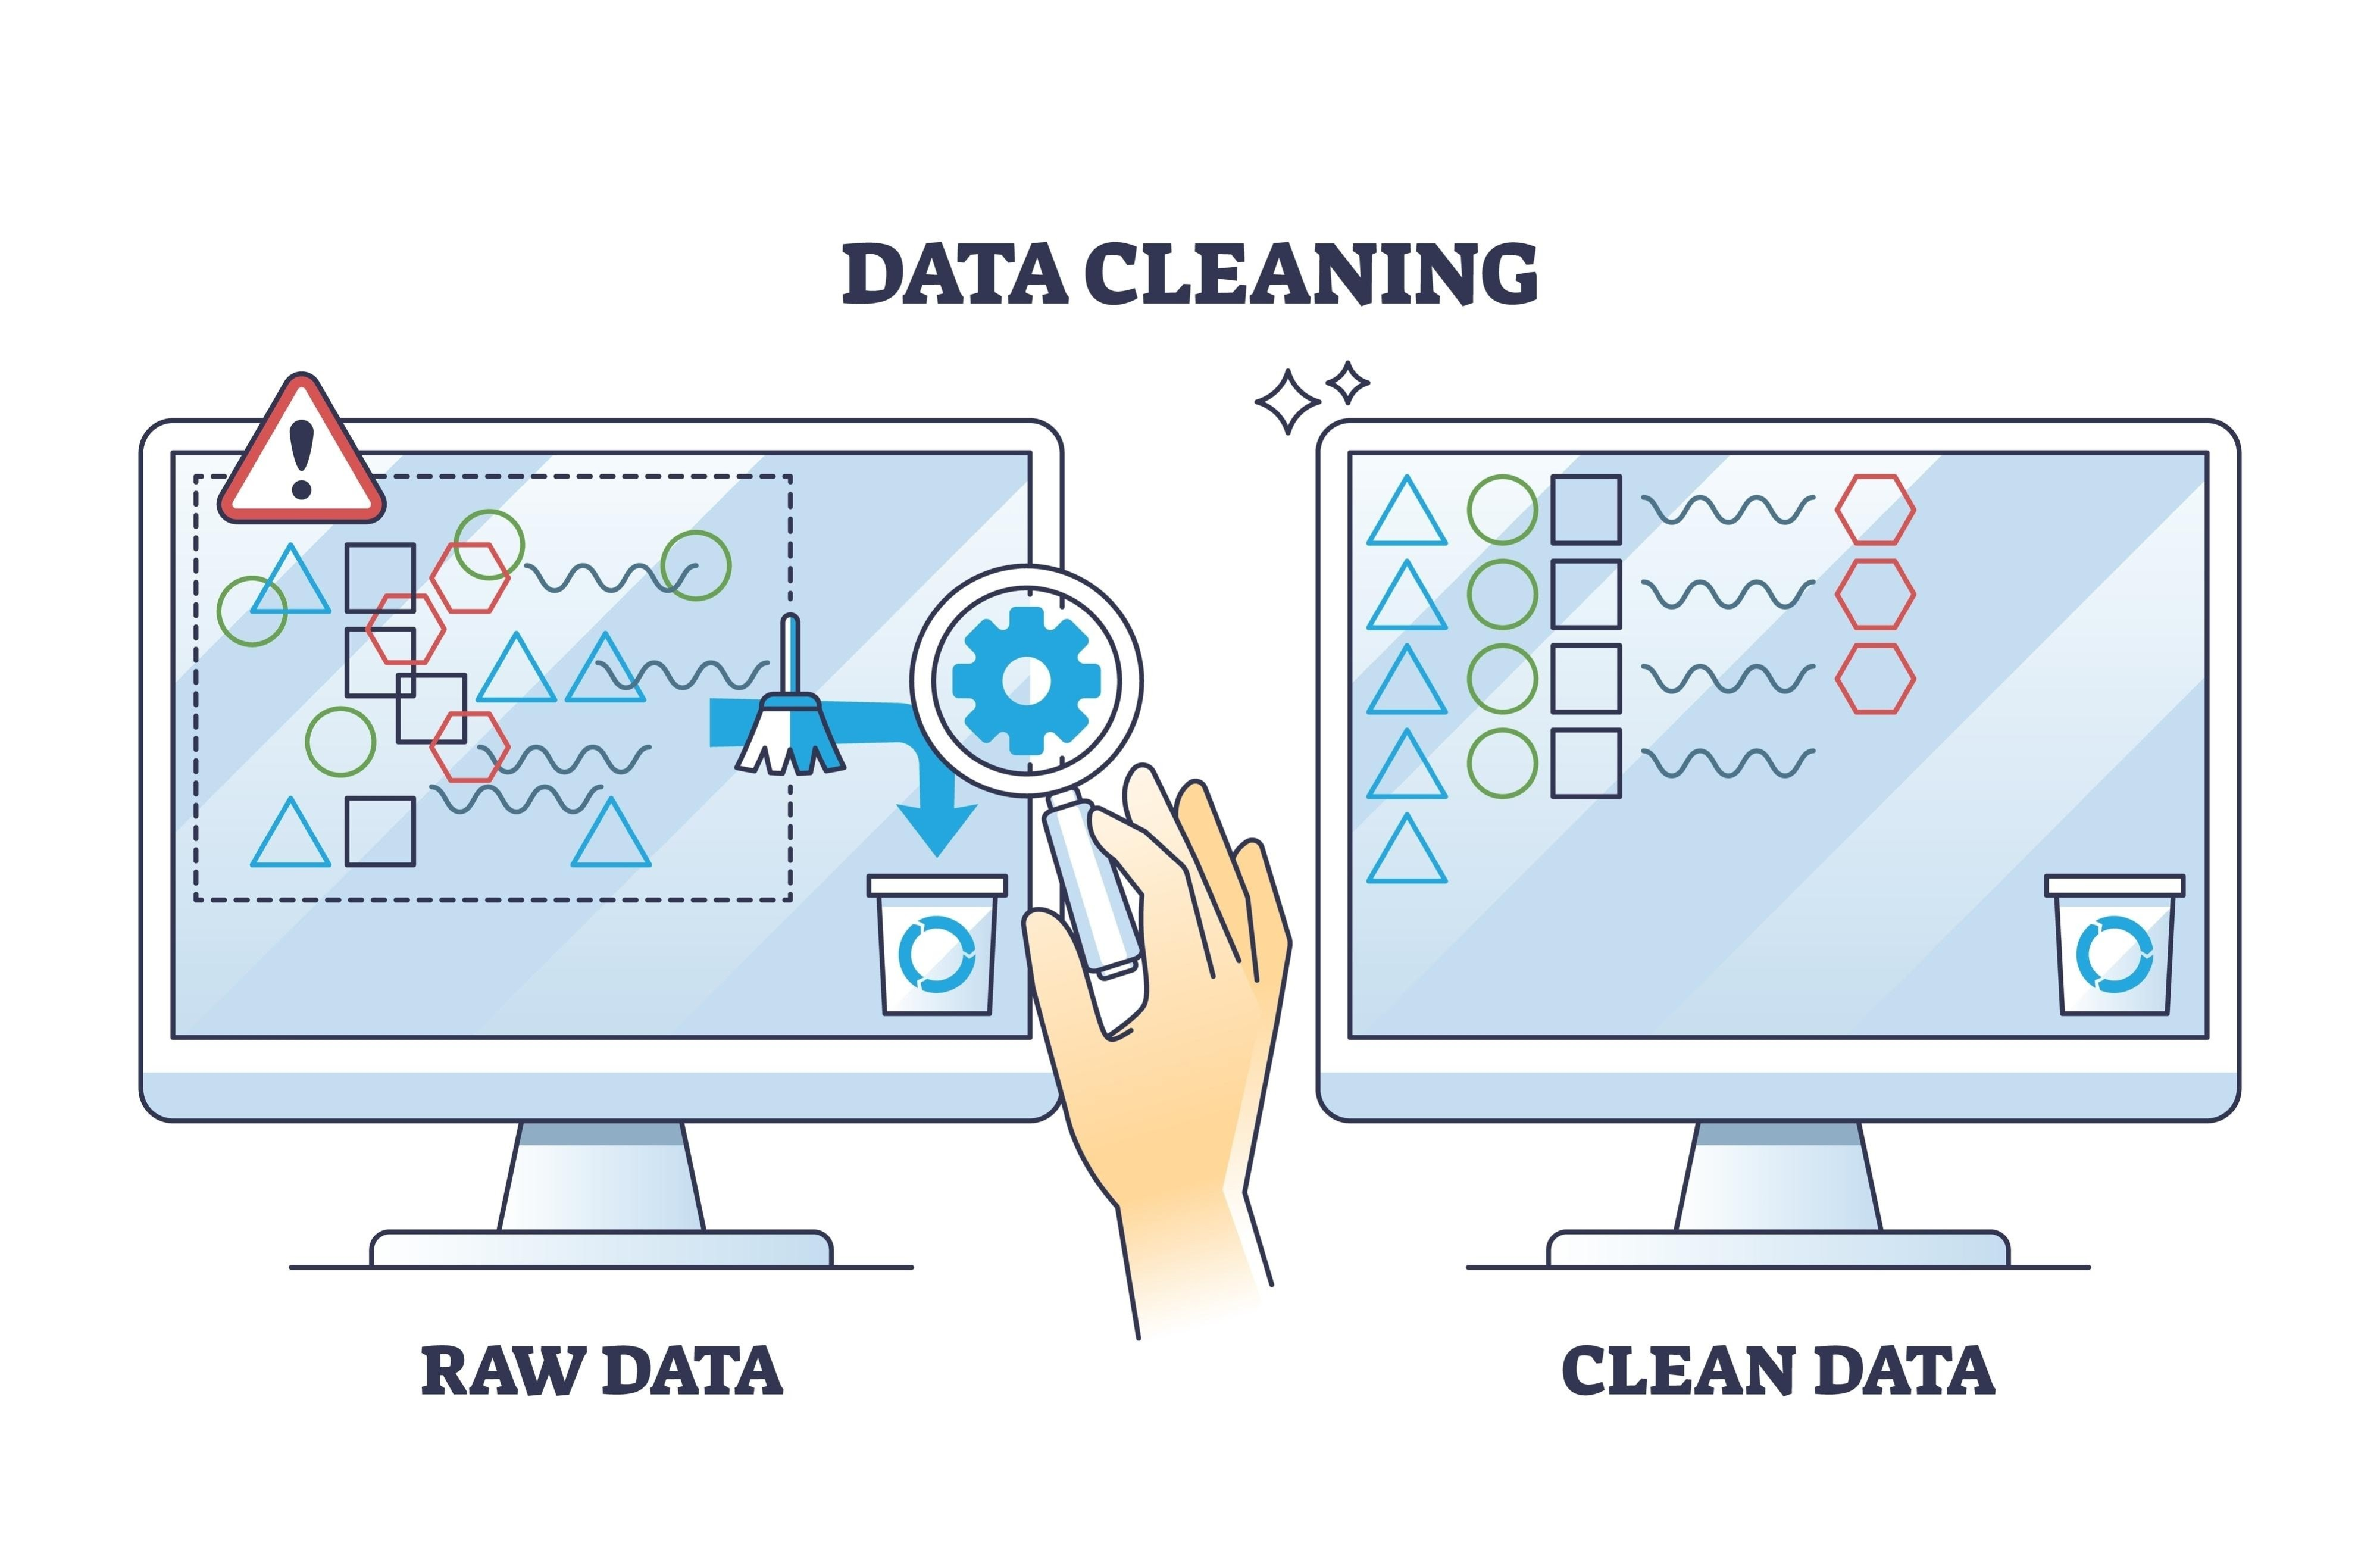

## 🚀 1.9. Tratamiento de Valores Nulos
Para garantizar que el análisis sea estadísticamente significativo y técnicamente eficiente, se han aplicado las siguientes reglas de procesamiento sobre el dataset de vehiculos nuevos registrados en el SRI:

Identificar las columnas que presentan más del 30 % de valores nulos para decidir su eliminación.
Adicional, se reviso las columnas por la varianza para eliminar aquellas que no sean necesarias.
En el caso de columnas críticas con pocos valores faltantes, se realiza la imputación de datos.

El código **analiza los valores nulos**, elimina las columnas con **más del 30 % de datos faltantes** y muestra un **comparativo del número de columnas antes y después** del proceso de limpieza.


In [6]:
# Obtiene el número total de columnas del DataFrame original
total_columnas_antes = df.shape[1]
total_columnas_antes  # Muestra el total de columnas antes del tratamiento

# Calcula el porcentaje de valores nulos por cada columna
nulos = (
    df.isna()          # Identifica valores nulos (NaN)
      .mean()          # Calcula la proporción de nulos por columna
      .mul(100)        # Convierte la proporción a porcentaje
      .round(2)        # Redondea a 2 decimales
      .reset_index()   # Convierte el índice en una columna
)

# Renombra las columnas del DataFrame resultante
nulos.columns = ['Columna', 'Porcentaje_nulos']

# Selecciona las columnas que tienen más del 30% de valores nulos
columnas_mayor_30 = (
    nulos[nulos['Porcentaje_nulos'] > 30]['Columna']
    .tolist()          # Convierte los nombres de columnas a una lista
)

# Elimina del DataFrame las columnas con más del 30% de nulos
df_reducido = df.drop(columns=columnas_mayor_30)

# "Las columnas que tienen un valor único... probablemente sean inútiles"
for col in df_reducido.columns:
    if df_reducido[col].nunique() == 1:
        print(f"Eliminando columna de varianza cero: {col}")
        df_reducido = df_reducido.drop(columns=[col])

print(f"Dimensiones post-limpieza básica: {df_reducido.shape}")

# Obtiene el total de columnas después de eliminar las columnas con muchos nulos
total_columnas_despues = df_reducido.shape[1]
total_columnas_despues  # Muestra el total de columnas después del tratamiento

# Crea un DataFrame resumen con el antes y después del tratamiento de columnas
resumen_columnas = pd.DataFrame({
    'Estado': ['Antes del tratamiento', 'Después del tratamiento'],
    'Total_columnas': [total_columnas_antes, total_columnas_despues]
})

# Muestra el resumen final
resumen_columnas


Dimensiones post-limpieza básica: (436602, 21)


,Estado,Total_columnas
0,Antes del tratamiento,21
1,Después del tratamiento,21


Luego de validar, nos percatamos que no existen columnas para eliminar.

### Filtrado por Umbral de Nulos (30%)
Se decidió eliminar automáticamente cualquier columna que presentara más del 30% de valores ausentes.
###¿Por qué?:
Una columna con un alto índice de nulos introduce sesgos y reduce la confiabilidad de cualquier modelo o gráfico. Al superar el 30%, la cantidad de datos "inventados" o imputados necesarios para rellenar.

### Reducción de Dimensionalidad
El paso de total_columnas_antes a total_columnas_despues no es solo una limpieza, es una optimización.
### ¿Por qué?:
Trabajar con un DataFrame más ligero permite que las operaciones en Python sean más rápidas y que el enfoque del análisis se mantenga en las variables que realmente tienen información completa y útil.

In [7]:
# Luego de validar, vamos a imputar los valores del dataset con nulos
# Tambien rellenaremos las columans que esten menor al 30%
print(f'Valores vacios a imputar {df.isna().sum()}')


Valores vacios a imputar categoria                        0
codigo_de_vehiculo               0
tipo_transaccion                 0
marca                            0
modelo                           0
pais                             0
ano_modelo                       0
clase                            0
sub_clase                        0
tipo                             0
avaluo                           0
fecha_proceso                    0
tipo_servicio                    0
cilindraje                       0
tipo_combustible                 0
fecha_compra                     0
canton                        1740
color_1                          3
color_2                      20525
persona_natural__juridica        0
provincia                     1740
dtype: int64


## 🚀 1.10. Tratamiento de outliers

Revisamos los outliers dentro del dataset y los elimaremos

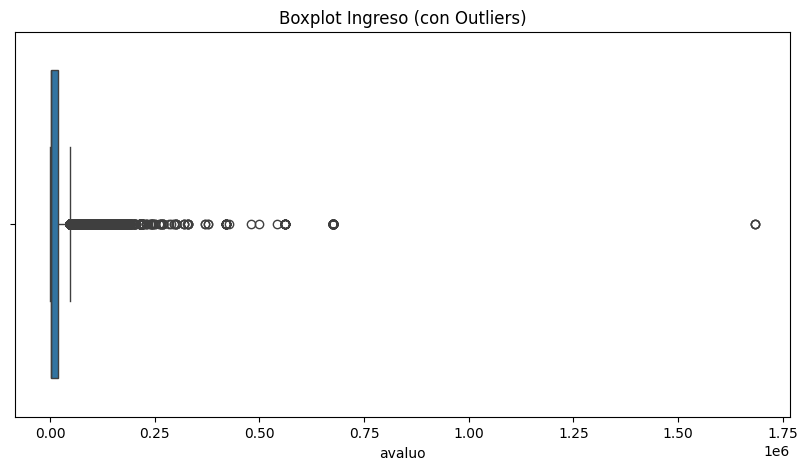

Outliers detectados en Ingreso: 16034
Rango aceptable: -26251.899999999998 a 47255.14


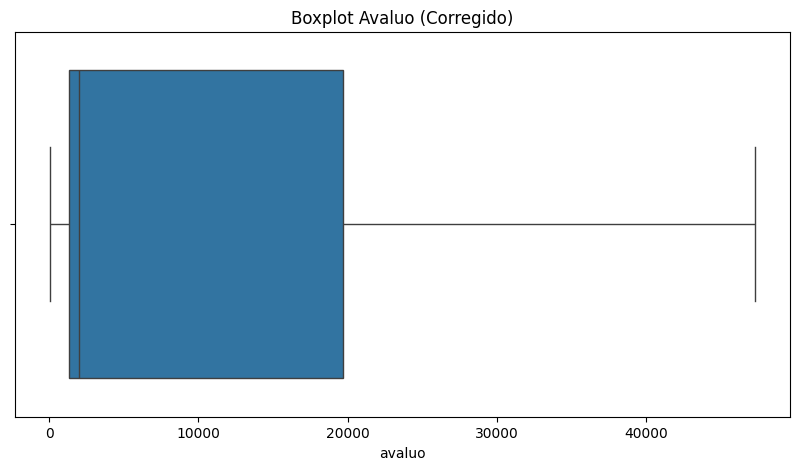

In [8]:
#Se reutiliza el metodo de deteccion de outliers revisado en clase
def detectar_outliers_iqr(dataframe, columna):
    Q1 = dataframe[columna].quantile(0.25)
    Q3 = dataframe[columna].quantile(0.75)
    IQR = Q3 - Q1
    limite_inferior = Q1 - 1.5 * IQR
    limite_superior = Q3 + 1.5 * IQR

    outliers = dataframe[(dataframe[columna] < limite_inferior) | (dataframe[columna] > limite_superior)]
    return outliers, limite_inferior, limite_superior

# Visualización antes de tratar
plt.figure(figsize=(10, 5))
sns.boxplot(x=df['avaluo'])
plt.title("Boxplot Ingreso (con Outliers)")
plt.show()

# Detectar
outliers_ingreso, li, ls = detectar_outliers_iqr(df, 'avaluo')
print(f"Outliers detectados en Ingreso: {len(outliers_ingreso)}")
print(f"Rango aceptable: {li} a {ls}")


# Tratamiento: Clipping (tope) en lugar de eliminar (Opcional, pero recomendado en industria)
df['avaluo'] = df['avaluo'].clip(lower=li, upper=ls)

# Visualización post-tratamiento
plt.figure(figsize=(10, 5))
sns.boxplot(x=df['avaluo'])
plt.title("Boxplot Avaluo (Corregido)")
plt.show()

## Exportación de dataset para analisis en Orange

Como parte de este proyecto necesitamos los datos del dataset identicos como se los analisaria en la herramienta de orange por lo tanto vamos a exportar el dataset hasta este punto.

In [13]:
# Exportación del archivo a un csv
bought_sold_cars_clean = 'Bought_Sold_Cars_Clean2025.csv'
pd.DataFrame(df).to_csv(bought_sold_cars_clean, index=False)

## 🚀 1.11. Validemos la correlación entre las variables

Vamos a realizar un analisis de correlación entre las variable para identificar la mejor opcion para seleccionar un target y sus features en nuestro dataset.

In [14]:
# Describimos todo el dataset refinado
df.describe()

# Analizando las posibles opciones pueden ser clase. categoria, ano_modelo, tipo y canton

print(f'Valores dentro del la columna clase {df["clase"].unique()}')
print(f'Valores dentro del la columna categoria {df["categoria"].unique()}')
print(f'Valores dentro del la columna año modelo {df["ano_modelo"].unique()}')
print(f'Valores dentro del la columna tipo {df["tipo"].unique()}')
print(f'Valores dentro del la columna canton {df["canton"].unique()}')



Valores dentro del la columna clase ['OMNIBUS' 'CAMIONETA' 'CAMION' 'MOTOCICLETA' 'AUTOMOVIL' 'VOLQUETA'
 'JEEP' 'TRAILER' 'ESPECIAL' 'TANQUERO']
Valores dentro del la columna categoria [104856 104844 104737 ...   6760   6296   1475]
Valores dentro del la columna año modelo [2026 2024 2023 2027 2022 2025 2020 2010 2021 2017 2019 2013 2014 2018
 2007 2008 2016 2015 2012 2011 2009 2003 1979 2005 2006 2002 2001 2000
 1993 1999]
Valores dentro del la columna tipo ['PESADO' 'LIVIANO']
Valores dentro del la columna canton ['QUITO' 'PASAJE' 'EL EMPALME' 'AMBATO' 'LATACUNGA' 'MANTA' 'GIRON'
 'SAN VICENTE' 'GENERAL ANTONIO ELIZALDE' 'SAN MIGUEL DE LOS BANCOS'
 'PUERTO QUITO' 'CUENCA' 'DAULE' 'JARAMIJO' 'MONTECRISTI' 'PUCARA'
 'GUAYAQUIL' 'ZAMORA' 'LA TRONCAL' 'SALCEDO' 'PICHINCHA' 'CAYAMBE' 'GUANO'
 'MACHALA' 'DURAN' 'PEDERNALES' 'CUMANDA' 'SANTO DOMINGO' 'PORTOVIEJO'
 'LA LIBERTAD' 'BALZAR' 'NOBOL (VICENTE PIEDRAHITA)' nan 'IBARRA'
 'PASTAZA' 'BABAHOYO' 'SALITRE' 'RIOBAMBA' 'SALINAS' 'GUALACEO

<Axes: >

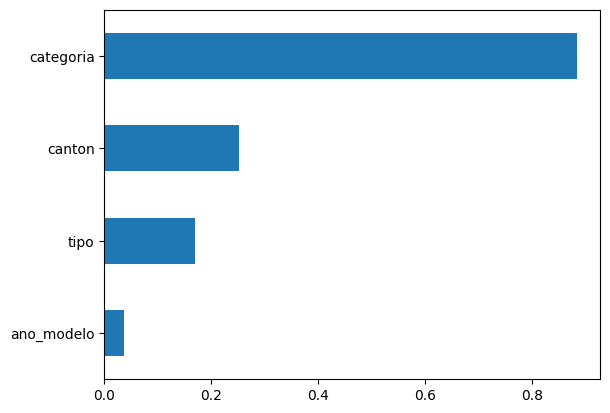

In [12]:
# Crearemos una matriz de correlacion de las columnas
from sklearn.feature_selection import mutual_info_classif
from sklearn.preprocessing import LabelEncoder

X = df[["categoria", "ano_modelo", "tipo", "canton"]]
y = df["clase"]

# Copia para no modificar original
X_encoded = X.copy()

# Codificar solo columnas categóricas
for col in X_encoded.select_dtypes(include="object").columns:
    le = LabelEncoder()
    X_encoded[col] = le.fit_transform(X_encoded[col].astype(str))

# Calcular MI
mi = mutual_info_classif(X_encoded, y)

mi_series = pd.Series(mi, index=X_encoded.columns)
mi_series = mi_series.sort_values(ascending=False)

# Graficaremos este resultado
mi_series.head(20).sort_values().plot(kind="barh")

Luego de analizar las variables usaremos la columna clase que es categorica.

El gráfico de Mutual Information muestra que categoria domina ampliamente la capacidad predictiva sobre clase, con un valor cercano a 0.9, lo que indica una relación extremadamente fuerte y posiblemente casi determinística entre ambas variables. En comparación, canton y tipo aportan información moderada, mientras que ano_modelo tiene una contribución prácticamente marginal. Esta distribución sugiere que el modelo dependerá principalmente de categoria para clasificar clase, lo que podría indicar que ambas variables están conceptualmente muy relacionadas o que existe una dependencia estructural directa; si categoria es una clasificación administrativa vinculada a clase, el desempeño del modelo podría estar inflado por esa relación casi directa más que por patrones complejos aprendidos de múltiples variables.

## 🚀 1.12. Implemente dos enfoques:


### 🚀 1.12.1. Enfoque incorrecto (con posible data leakage).

Como hemos ya limpiado los datos, necesitamos realizar la imputación para rellenar los valor vacio o inexistentes en el dataset. Como queremos caer en el enfoque que nos de un posible data leakage.

In [11]:
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier

# Separar X e y
X = df[["categoria", "ano_modelo", "tipo", "canton"]]
y = df["clase"]

# 🚨 LEAKAGE: imputamos usando TODO el dataset
imputer = SimpleImputer(strategy="most_frequent")
X_imputed = imputer.fit_transform(X)

# Codificamos categóricas usando TODO el dataset
X_encoded = pd.DataFrame(X_imputed, columns=X.columns)

for col in X_encoded.select_dtypes(include="object").columns:
    le = LabelEncoder()
    X_encoded[col] = le.fit_transform(X_encoded[col].astype(str))

# Split después (ya contaminado)
X_train, X_test, y_train, y_test = train_test_split(
    X_encoded, y, test_size=0.3, random_state=42
)

model = RandomForestClassifier(random_state=42)
model.fit(X_train, y_train)

print("Accuracy con leakage:", model.score(X_test, y_test))



Accuracy con leakage: 0.9538177292889809


Ese 0.9538 (95.38%) es exactamente lo que uno espera cuando hay data leakage + una variable casi determinística.

Recordemos que el MI:

categoria ≈ 0.9 con respecto a clase.

Eso ya indicaba que categoria contiene casi toda la información necesaria para predecir clase.

Ese 95% está inflado principalmente por la relación casi determinística entre categoria y clase, más que por capacidad real de generalización del modelo.

### 🚀 1.12.2. Enfoque correcto utilizando Pipeline de sklearn.

Como hemos ya verificamos que tenemos data leakage provocado intencionalmente entonces tenemos que realizar las correcciones para mejorar nuestro accurancy.


In [22]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer

# Repetimos el mismo codigo pero hacemos el split inicialmente antes de las imputaciones.
# Tambien vamos agregr pipeline para automatizar el proceso
# Separar X e y
X = df[["categoria", "ano_modelo", "tipo", "canton"]]
y = df["clase"]

# ✅ 1. Split PRIMERO
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

# Identificar columnas
num_cols = ["ano_modelo"]
cat_cols = ["categoria", "tipo", "canton"]

# Transformaciones
numeric_transformer = SimpleImputer(strategy="median")

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore"))
])

# ColumnTransformer
preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, num_cols),
        ("cat", categorical_transformer, cat_cols)
    ]
)

# Pipeline completo
model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", RandomForestClassifier(n_estimators=50,
        random_state=42,
        n_jobs=-1))
])

# Entrenar
model.fit(X_train, y_train)

# Evaluar
print("Accuracy sin leakage (Pipeline):", model.score(X_test, y_test))

Accuracy sin leakage (Pipeline): 0.9571311869660485


En este resultado notamos que tenemos un porcentaje similar en que la data con enfoque incorrecto, eso significa que estamos haciendo algo mal?

Pues el problema es que el feature de "categoria" es una variable muy dependiente del target y eso produce que al tener una relacion muy deterministica ya tiene la respuesta de una prediccion en la entrada y eso hace que el modelo no tenga predicciones a patrones complejos y nos puede dar muchos resultados irreales.

Lo ideal seria eliminar la columna y seguir refinando la data puede ser normalizandola mas o realizar otras tecnicas que nos permita llegar a un porcentaje realista que nos de un modelo mas completo.

Cuando se elimina la columna se puede notar que llega al 70% y eso hace que el modelo sea mas realista y puede mejorar mas con otras tecnicas.

## 🚀 1.13. Compare métricas utilizando validación cruzada.


In [24]:
# Importamos la libreria
from sklearn.model_selection import StratifiedKFold, cross_val_score
import numpy as np

# Validación cruzada estratificada
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

scores = cross_val_score(model, X, y, cv=cv, scoring="accuracy")

print("Accuracy por fold:", scores)
print("Accuracy promedio:", np.mean(scores))
print("Desviación estándar:", np.std(scores))


Accuracy por fold: [0.95879571 0.96008978 0.95865781 0.958612   0.95931058]
Accuracy promedio: 0.959093177083162
Desviación estándar: 0.0005567856466095971


## 🚀 1.14. Analice los resultados y explique el impacto arquitectónico.


### 🧠 Interpretación

Los resultados del proyecto muestran que la variable categoria mantiene una relación estructural extremadamente fuerte con el target clase. Esto se evidenció inicialmente con un valor alto de Mutual Information (~0.9) y posteriormente con un accuracy cercano al 96% cuando se incluía en el modelo.

La validación cruzada estratificada confirmó esta estabilidad, arrojando accuracies por fold de aproximadamente 0.9588, 0.9601, 0.9587, 0.9586 y 0.9593, con un promedio de 0.9591 y una desviación estándar muy baja (~0.00056). Esto indica que el desempeño es consistente entre particiones y que el modelo generaliza de manera estable; sin embargo, dicha precisión se debe principalmente a la fuerte dependencia informacional entre categoria y clase.

Al eliminar categoria, el accuracy descendió a aproximadamente 71%, lo que demuestra que gran parte del poder predictivo provenía de esa variable dominante. En consecuencia, aunque el modelo con categoria predice con alta exactitud, su valor analítico es limitado si esta variable es conceptualmente redundante o derivada del target. Desde una perspectiva arquitectónica, incluir categoria transforma el problema en uno casi trivial y reduce artificialmente su complejidad, mientras que el modelo sin ella refleja de forma más realista la capacidad de generalización basada en variables independientes, ofreciendo una evaluación más honesta del desempeño predictivo del sistema. texto en negrita.

#2️⃣ Fase 2: Diseño Visual en Orange


## 📑 Construya un flujo con los siguientes widgets:
- File
- Select Columns
- Normalize
- Test & Score
- Confusion Matrix

En el siguiente apartado esta las capturas del diseño arquitectonica con la herramienta de Orange Data Mining.

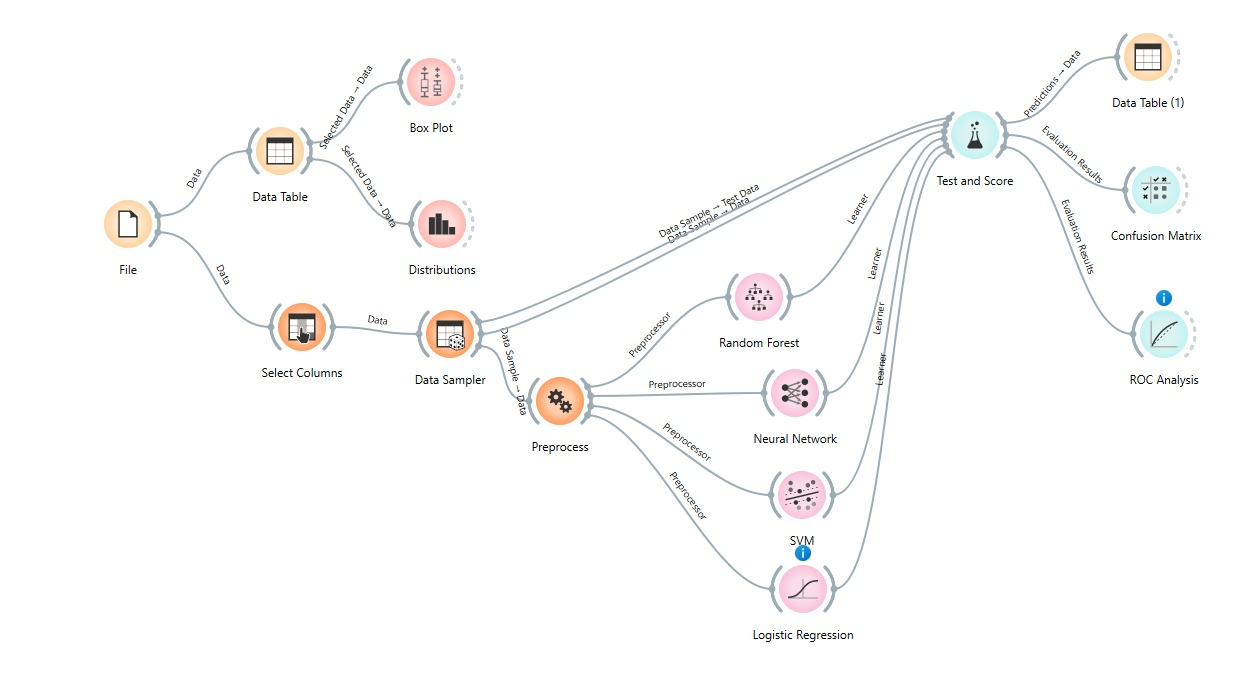



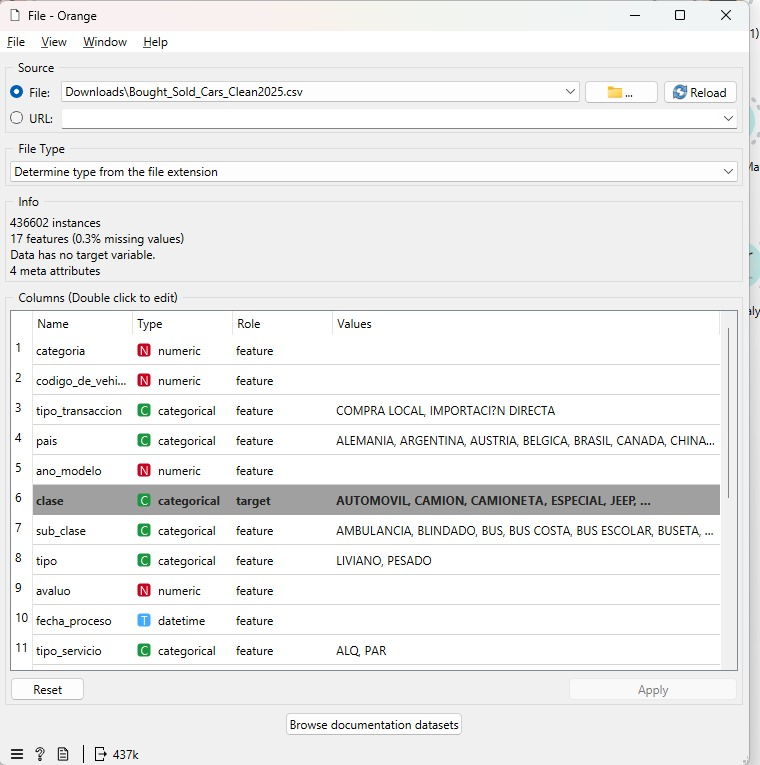

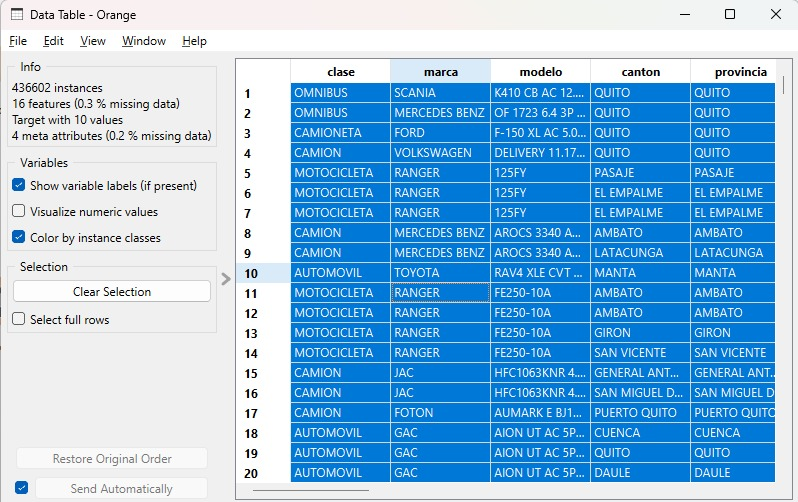

## 📑 Compare al menos tres modelos.

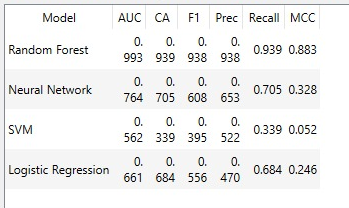

Como se muestra en la imagen se realizo con tres modelos:

- Random Forest
- Neural Network
- SVM
- Regresion Logica

El mejor modelo para nuestro dataset en resultados ha sido random Forest que se puede visualizar su accurancy de 99% que es muy cercano a lo realizado en el proyecto dentro de este colab. Sin embargo, se debe considerar que se realizón con menos datos porque no se pudo usar todo el dataset en la herramienta que si se pudo realizar en este proyecto. Esto solamente respalda los arguemntos que anteriormente se expusieron aunque la red neuronal tambine nos proporciono un resultado cercano pero concluimnos en lo mismo mencionado anteriormente.

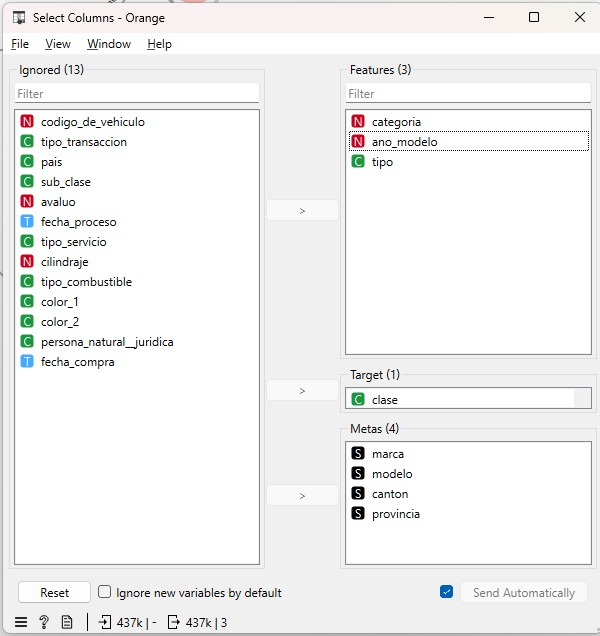
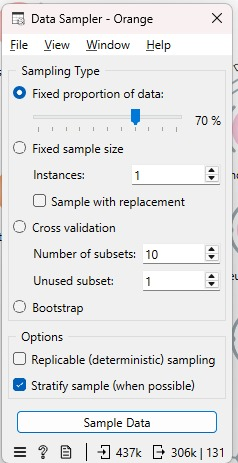
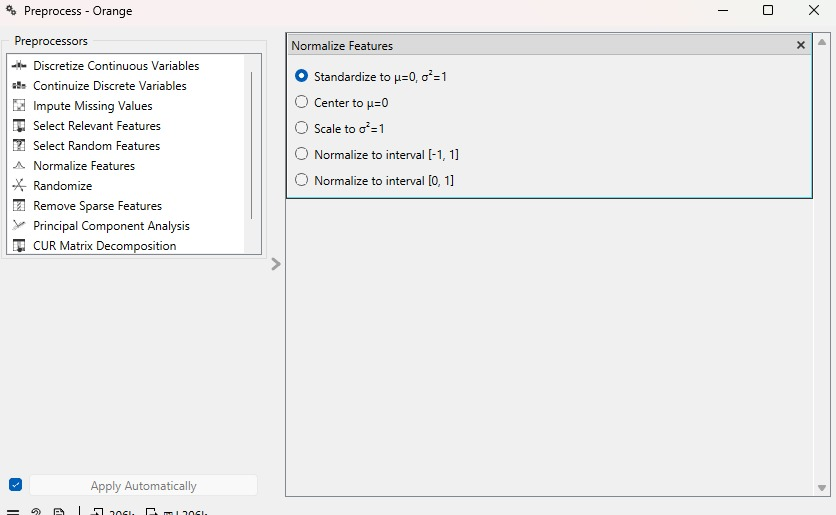
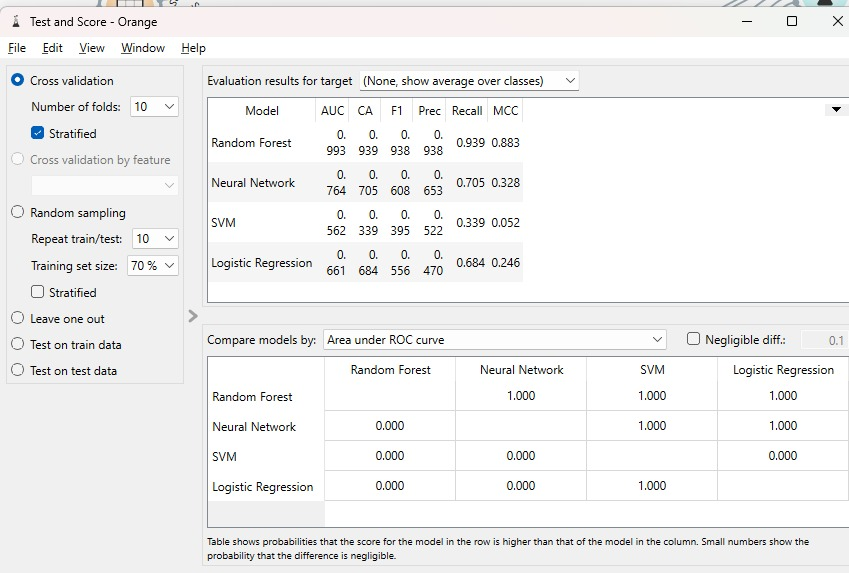

## 📑 Analice diferencias con y sin normalización.

En la herramienta aunque pasamos con datos normalizados, Sin embargo, si no se hubiera aplicado normalización, eso no cambiaría de forma relevante los resultados obtenidos, porque el modelo que estamos utilizando (Random Forest dentro de un Pipeline con árboles de decisión) no es sensible al escalamiento de variables. Los árboles dividen el espacio mediante reglas del tipo feature < threshold, por lo que solo importa el orden relativo de los valores, no su magnitud absoluta. Escalar una variable (por ejemplo, pasar de 0–1000 a 0–1) no altera el punto de corte óptimo, solo cambia la representación numérica.

Por lo tanto, si no se hubiera normalizado, se puede concluir que el accuracy (~96% con categoria) y el TPR = 1 no están explicados por efectos de escala, sino por la estructura informacional del dataset, particularmente por la fuerte dependencia entre categoria y clase. En otras palabras, el desempeño observado no depende de normalización, sino de la arquitectura del problema y la redundancia entre variables.

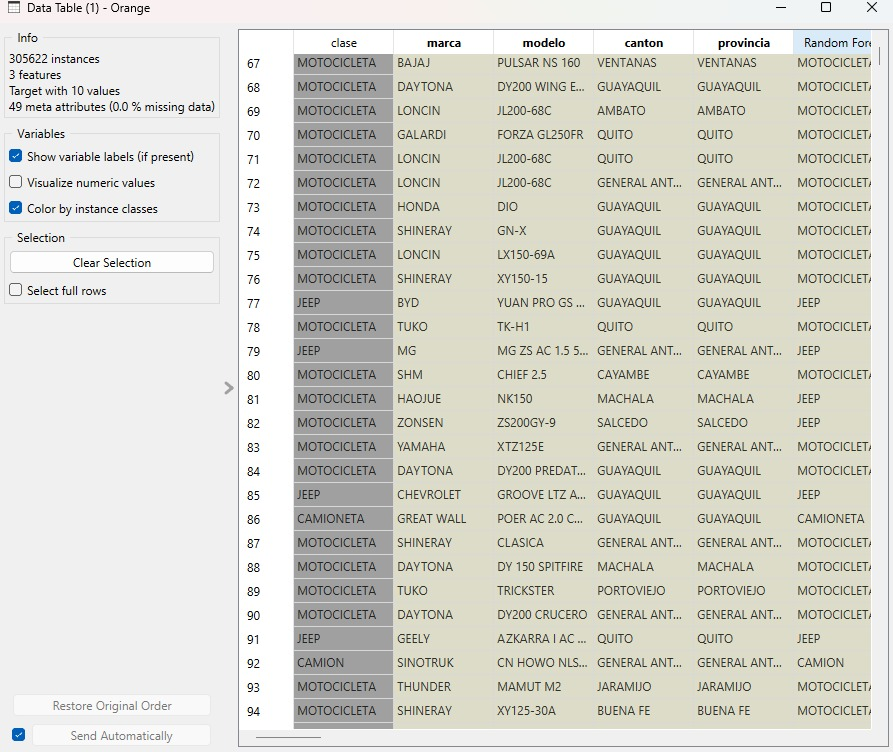
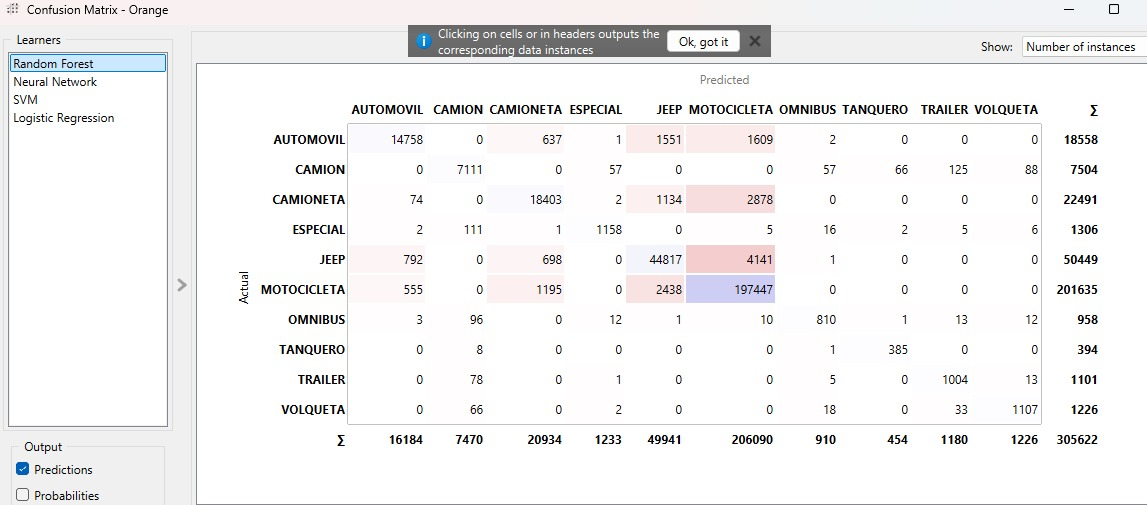
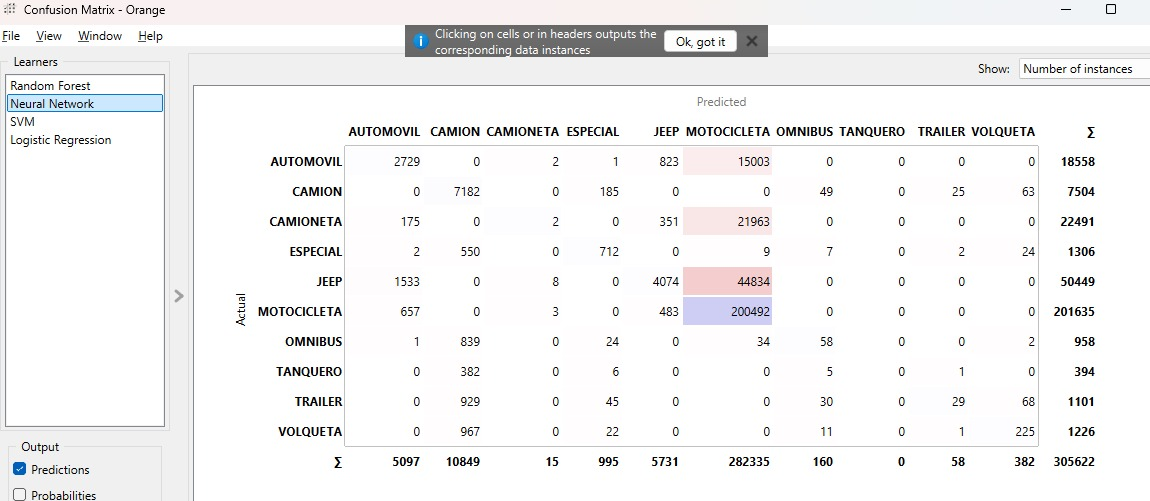

## 📑 Discuta qué modelos son sensibles al escalamiento y por qué

Que el TPR (True Positive Rate) de una clase sea igual a 1 significa que el modelo está identificando correctamente el 100% de los casos reales de esa clase, es decir, no está cometiendo falsos negativos para ella. En términos prácticos, todos los registros que realmente pertenecen a esa clase fueron clasificados correctamente. Sin embargo, esto no implica necesariamente que el modelo sea perfecto, ya que aún podría estar generando falsos positivos. En el contexto de tu proyecto, especialmente si se incluye la variable categoria, un TPR = 1 puede explicarse por una fuerte dependencia estructural entre las variables, lo que facilita una separación casi determinística más que un aprendizaje profundo de patrones independientes. Además, dado que estamos  utilizando un Random Forest, el modelo no es sensible al escalamiento de variables, ya que los árboles de decisión se basan en particiones por umbrales y no en distancias o magnitudes; por lo tanto, el valor perfecto del TPR no está relacionado con efectos de normalización o estandarización, sino con la estructura informacional del dataset.


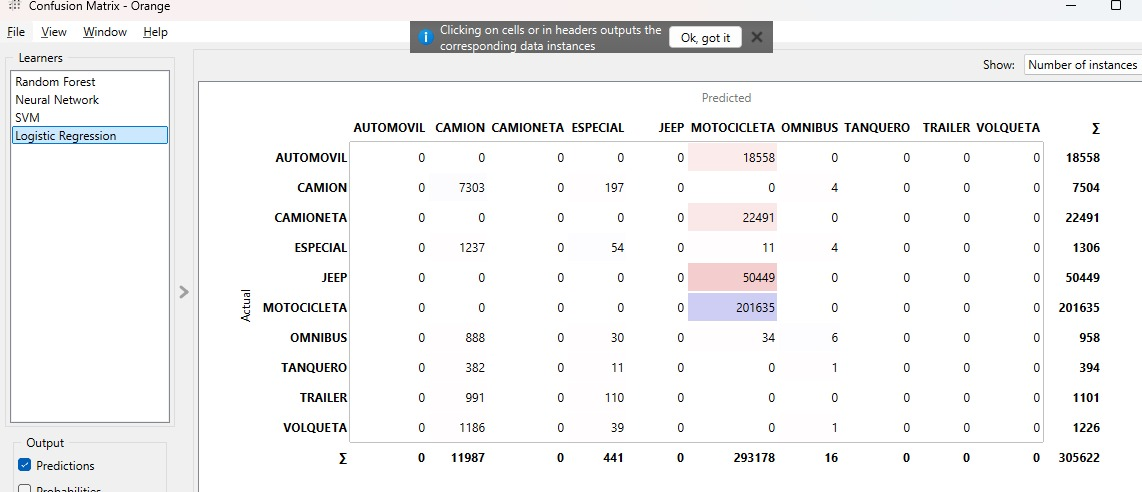
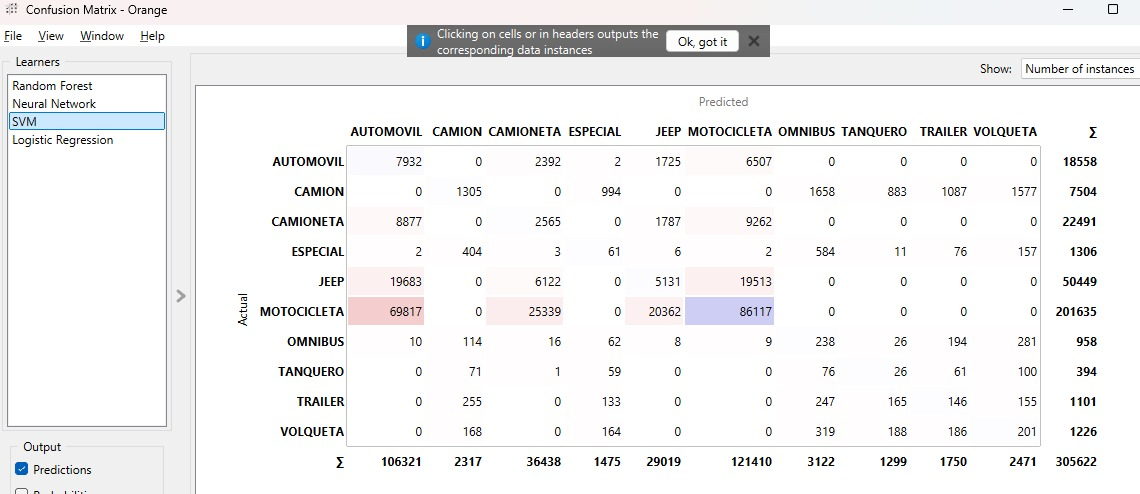
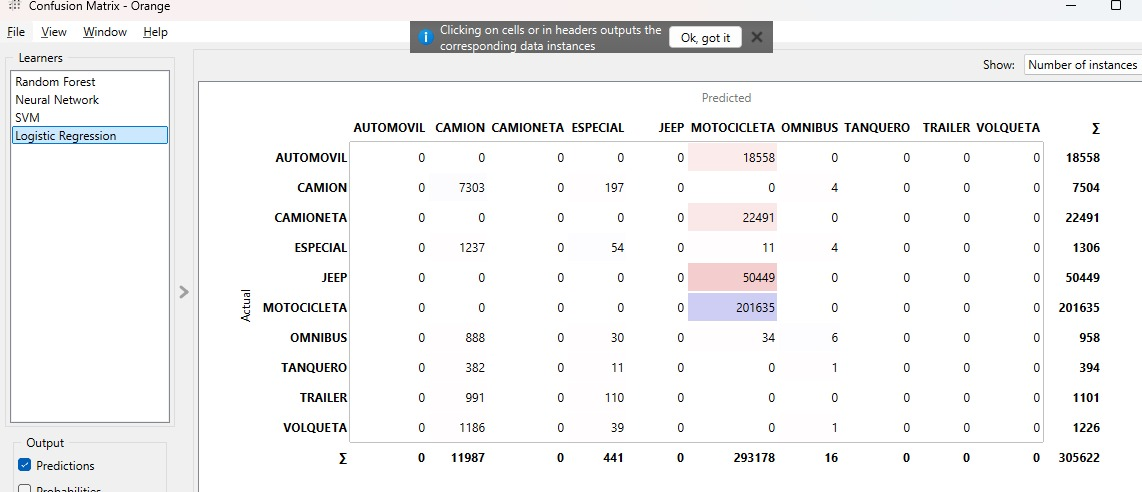
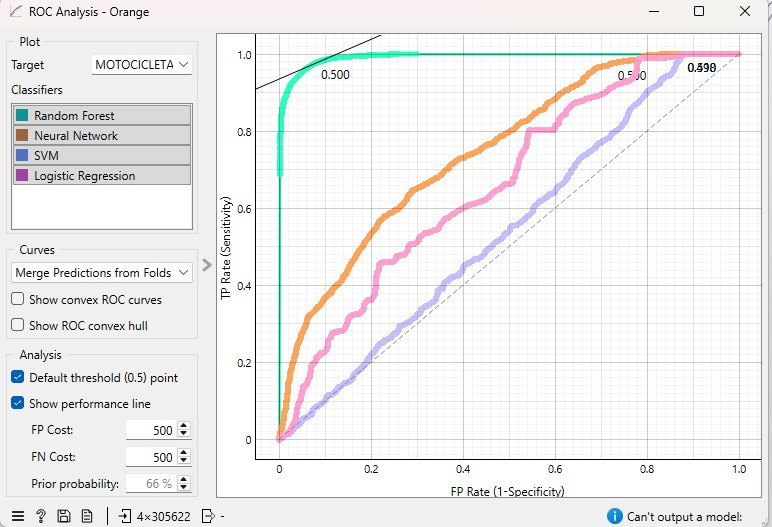

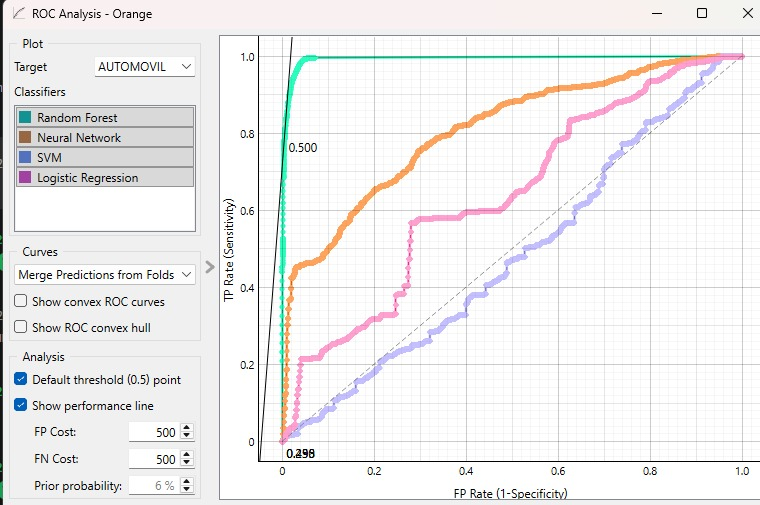
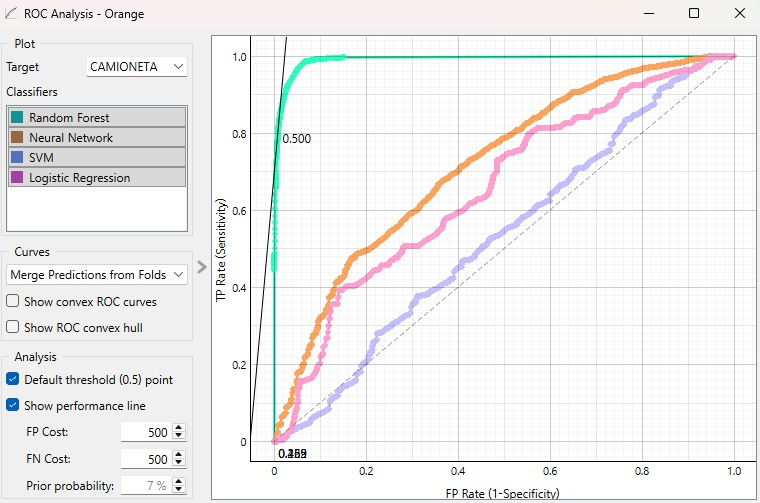
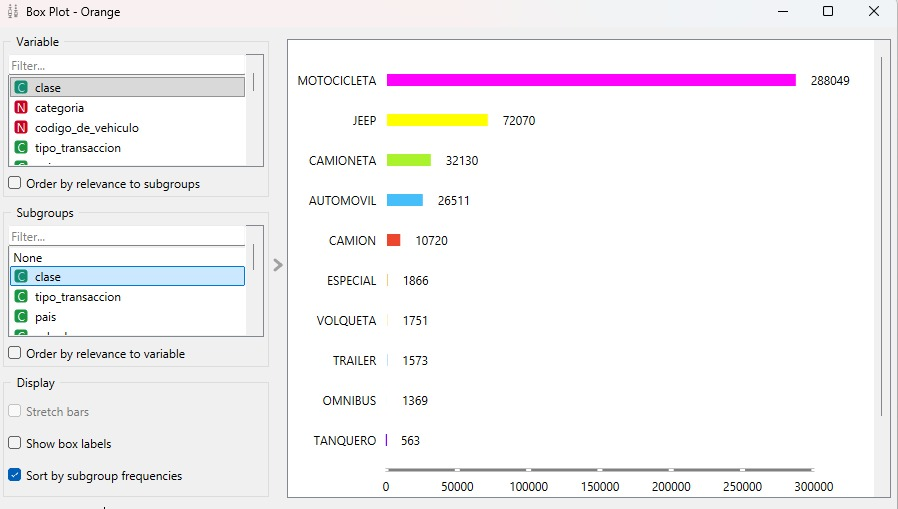
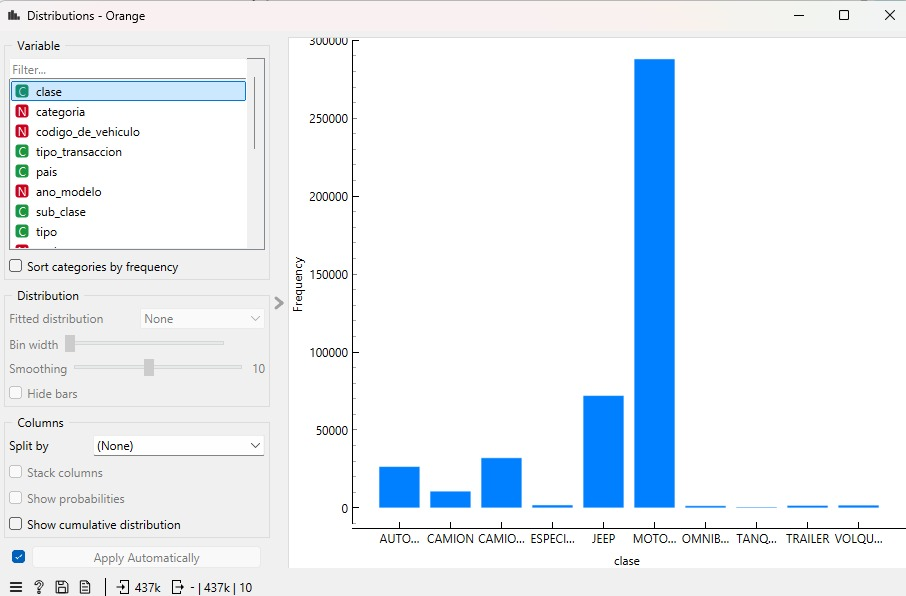
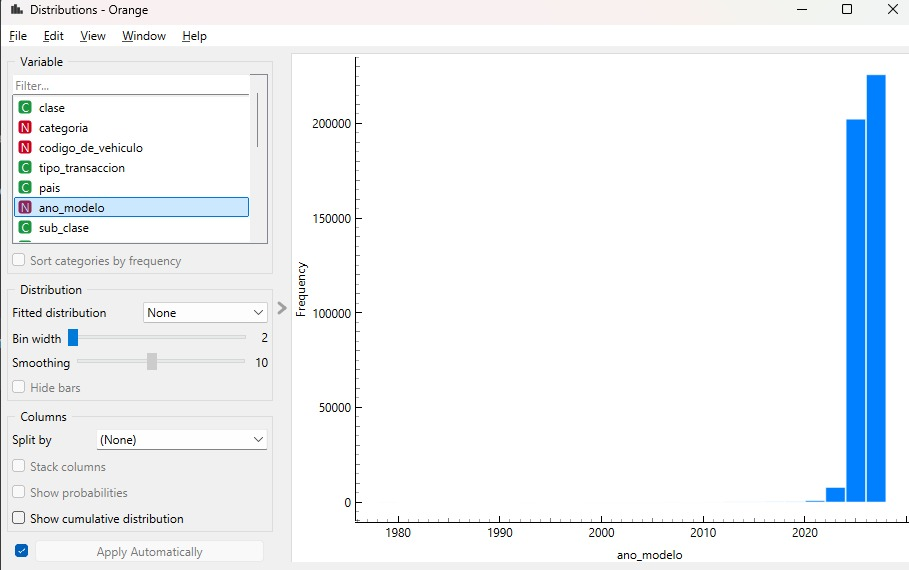

# 3️⃣ Fase 3: Reflexión Arquitectónica

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.9/24.9 MB 38.6 MB/s eta 0:00:00


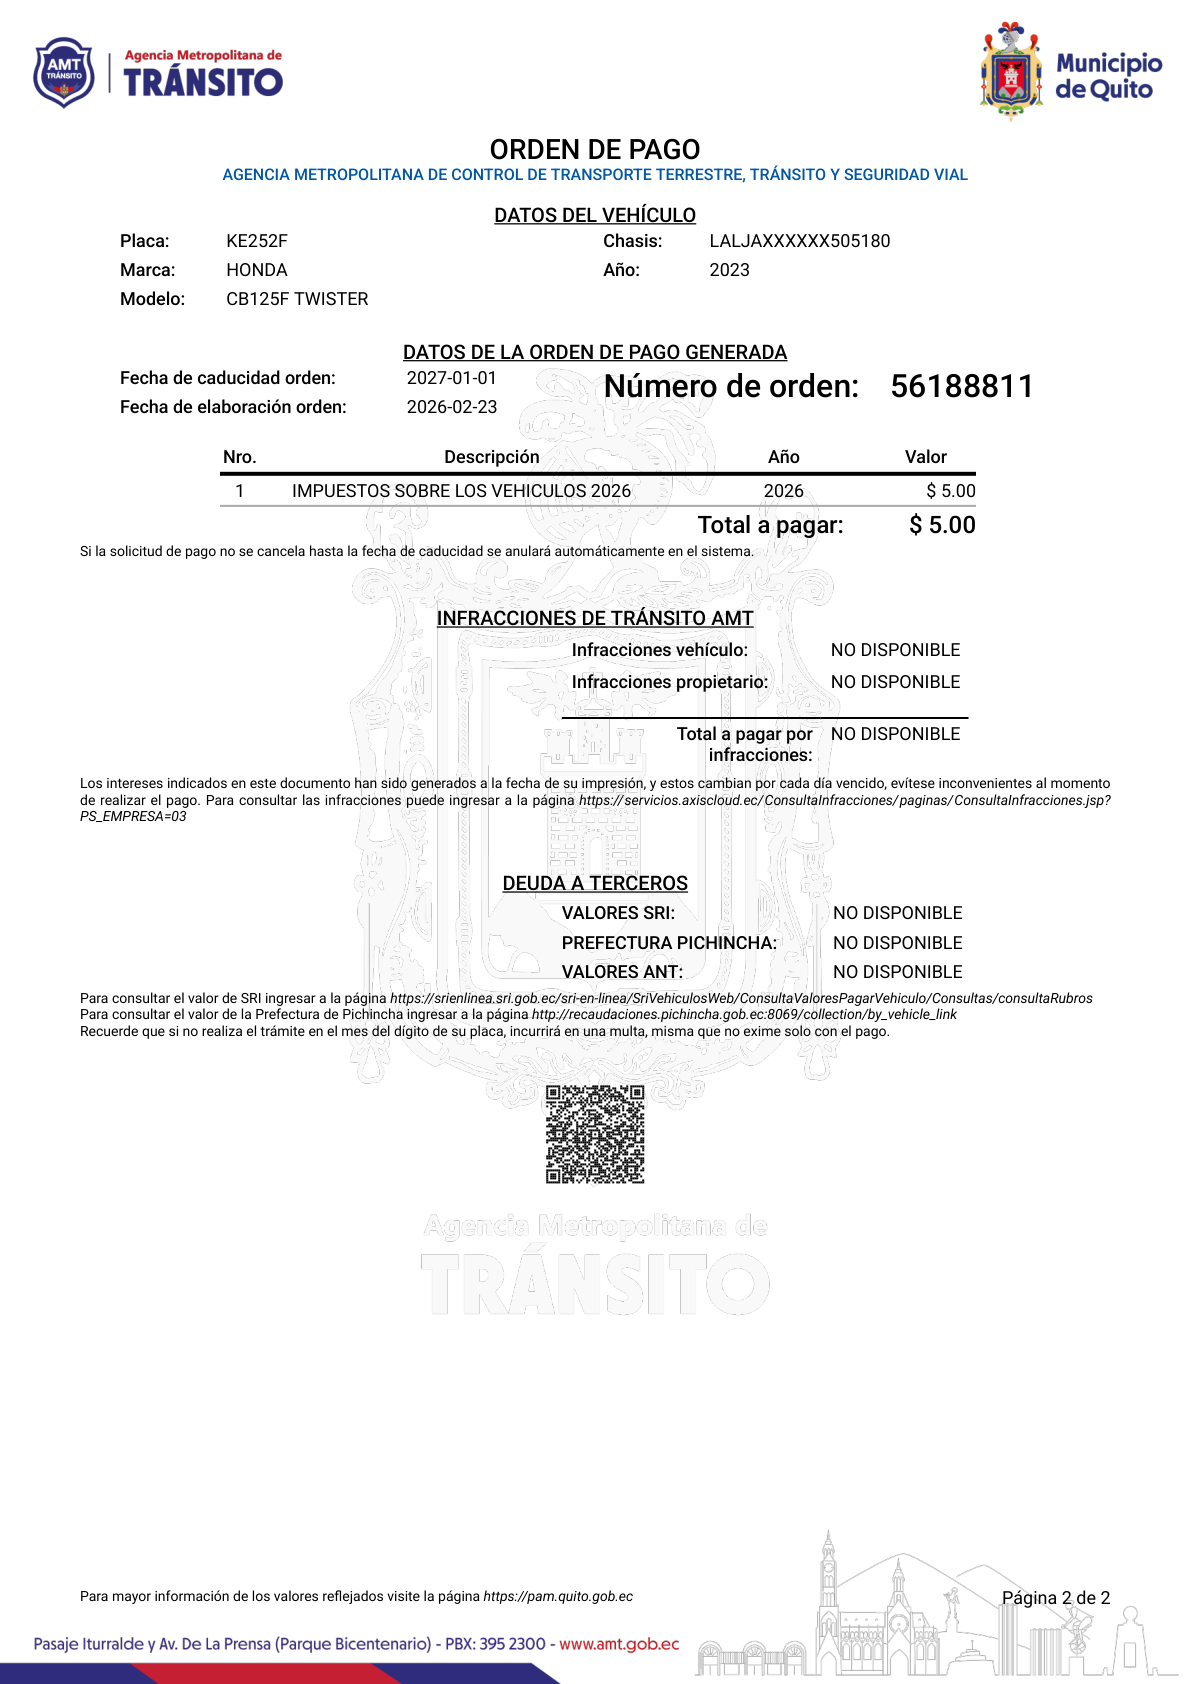

In [29]:
# 1. Instalar la librería necesaria
!pip install pymupdf -q

import fitz # PyMuPDF
from PIL import Image
from IPython.display import display

# 2. Reemplaza con tu nombre de archivo
file_path = 'KE252F.pdf'

# 3. Abrir y mostrar la primera página
doc = fitz.open(file_path)
page = doc.load_page(0)  # 0 es la primera página
pix = page.get_pixmap(matrix=fitz.Matrix(2, 2)) # Matrix(2,2) mejora la resolución
img = Image.frombytes("RGB", [pix.width, pix.height], pix.samples)

display(img)

# 4️⃣ Fase 4: Conclusiones del proceso y análisis de datos

Agregue sus conclusiones, desarrollando un análisis integral de todo el proceso
realizado. En su reflexión, identifique y explique:

- ¿Qué aspectos del proceso fueron más aplicables o efectivos?
- ¿Cuáles fueron los elementos más complejos o desafiantes?
Sustente sus respuestas con argumentos claros y, de ser posible, con ejemplos
derivados de su experiencia durante el desarrollo de la actividad.

## 🚀 4.1. ¿Qué aspectos del proceso fueron más aplicables o efectivos?


## ⭐ Respuesta

Nuestra opinión sobre este proyecto es sobre todo el uso de librerias para empezar a realizar el entrenamiento de la data que ya hemos aprendido a limpiar, seleccionar, tranformar. En este dataset de los vehiculos nuevos registrados por el SRI podemos reconocer varios patrones en la información que tiene esta organización gubernamental que nos puede ayudar a entender cual es la tendecia de compra tanto de casas de venta como de las personas del país que importan del exterior.

El aprender hacer un pipeline para automatizar tanto la imputación como la codificacion, entro aspectos. Nos permite realizar un modelo predictivo eficiente que puede usarse para aplicativos y de sugerencias efectivas para optimizar procesos. Sin embargo, necesitamos mas tiempo para entrenarlo de mejor manera ya que tenemos un modelo que tiene una predicción eficiente hasta cierto nivel de complejidad. Aunque las validaciones cruzadas nos dicen lo contrario pero siempre da la duda por los entrenamientos con los dos enfoques y tenemos que mejorar en ese aspecto.



## 🚀 4.2. ¿Cuáles fueron los elementos más complejos o desafiantes?


## ⭐ Respuesta

El mayor reto es limpiar el dataset y seleccionar el correcto target con sus features. Hay que recordar que entre lo que deseamos analizar debe ser el target que queremos definir y luego las caracteristicas que ayudaran al modelo en su prediccion para obtener una predicción coherente.

Sin embargo, se eligió una columna que tiene una relacion determinante con otra y eso da un gran dependencia una con la otra que puede darnos predicciones muy simples pero si colocamos más complejidad para que el modelo lo prediga puede ser que no proporcione un resultado optimo y real. Tambien realizar la correlacion con un target de categorias, la opcion que teniamos era hacerla numeros o hacer un MI(Mutual Information) que en escencia es lo mismo pero para este categoria de target.


En conclusión, tenemos aun el desafio de mejorar el modelo y escoger otro enfoque para que estos datos proporcionen un modelo más util para una entidad como el SRI si en caso deseará usarla en un aplicativo o una entidad externa.

# 5️⃣ Fase 5: Aplicación al entorno profesional

## 🚀 Redacta una sección final de aplicación:
- Cada miembro del equipo colocara su nombre una explicación de como aplicaría
lo aprendido en esta semana en su entorno profesional.

# 🖥️ **Christian Carrera**

En mi trabajo no tengo mucho que sacar interpretaciones de datos pero la practica me es util en mi trabajo con Python que permitirá generar gráficos para los informes y tambien realizar correlaciones en el momento que necesite.

La información es importante para la empresa donde trabajo porque es una empresa bancaria pero no estoy en un area donde pueda aplicar 100% estos conocimientos pero puedo dar propuestas que espero que sirvan para mejorar aplicativos existentes.

# **Alexander Luna**

El dominio de pipelines profesionales y la prevención de data leakage me servirá para diseñar sistemas de calificación registral automatizada que garanticen la seguridad jurídica. La implementación de estas arquitecturas me permitirá asegurar que los modelos predictivos sean auditables, reproducibles y libres de sesgos estadísticos. Esto será fundamental para transformar la gestión de datos registrales en un proceso eficiente que mantenga la integridad del linaje de la información y la fe pública institucional.

# **Romel Cerna**

Lo aprendido esta semana lo aplico directamente en mi rol como soporte de aplicaciones bancarias, ya que ahora puedo analizar datos y logs con mayor criterio técnico, detectar errores en procesos de transformación y comprender la importancia de evitar data leakage. Además, entiendo mejor cómo integrar correctamente las transformaciones dentro de un pipeline para garantizar coherencia entre entrenamiento y producción. El uso de técnicas como preprocesamiento, muestreo, validación cruzada y comparación de modelos me permite evaluar métricas con sentido crítico, identificar patrones y comportamientos atípico